In [2]:
import glob

images_path = glob.glob("../data/PNG/crop_and_pad/*")

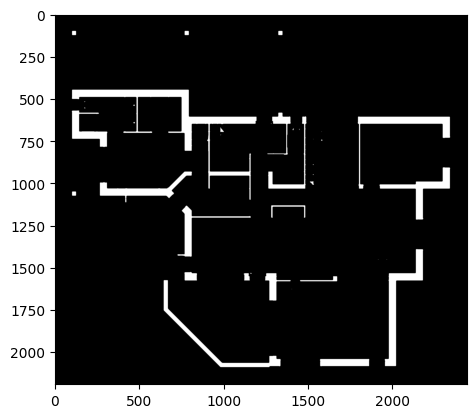

In [2]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(images_path[0], cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
plt.imshow(img, cmap="gray")
plt.show()

In [3]:
import numpy as np

# ── Step 1: Crop matplotlib border/axes ──
# Find bounding box of ALL white pixels, then add margin to exclude axis ticks
coords = np.column_stack(np.where(binary > 0))
y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

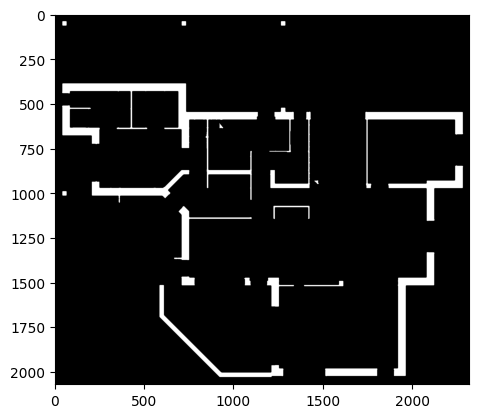

In [4]:
# Add small padding inward to exclude the outermost axis line
margin = -40
cropped = binary[y_min+margin:y_max-margin, x_min+margin:x_max-margin]

# ── Step 2: Remove small isolated noise dots ──
# Use area filtering via connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    cropped, connectivity=8
)

# Calculate median area of components (floor plan walls will be large)
areas = stats[1:, cv2.CC_STAT_AREA]  # skip background

# Keep only components larger than threshold
# Use 1% of image area as minimum, or median-based threshold
min_area = max(100, np.median(areas) * 0.5) if len(areas) > 0 else 100

cleaned = np.zeros_like(cropped)
for label_id in range(1, num_labels):
    if stats[label_id, cv2.CC_STAT_AREA] >= min_area:
        cleaned[labels == label_id] = 255

plt.imshow(cleaned, cmap="gray")
plt.show()

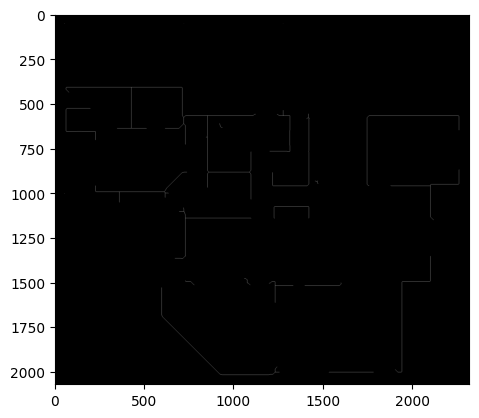

In [5]:
from skimage.morphology import skeletonize
from skimage import img_as_bool

# Skeletonize
skeleton = skeletonize(img_as_bool(cleaned))
skeleton = (skeleton * 255).astype(np.uint8)
plt.imshow(skeleton, cmap="gray")
plt.show()

In [6]:
skel_bin = (skeleton > 0).astype(np.uint8)

kernel = np.ones((3, 3), dtype=np.uint8)
kernel[1, 1] = 0
neighbor_count = cv2.filter2D(skel_bin, -1, kernel)

# ── Type 1: T / X junctions (3+ neighbors) ──
branch_mask = (skel_bin == 1) & (neighbor_count >= 3)

# ── Type 2: L-corners (exactly 2 neighbors, but at 90°) ──
# Use Harris corner detector on the skeleton itself
skel_float = skel_bin.astype(np.float32)
harris = cv2.cornerHarris(skel_float, blockSize=3, ksize=3, k=0.04)
harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX)

# Threshold harris response on skeleton pixels only
corner_mask = (harris_norm > 30) & (skel_bin == 1)

# ── Type 3: Endpoints (degree 1) — optional, wall tips ──
endpoint_mask = (skel_bin == 1) & (neighbor_count == 1)

# ── Combine all ──
combined_mask = branch_mask | corner_mask  # add endpoint_mask if needed

coords = np.column_stack(np.where(combined_mask))[:, ::-1]  # (x, y)

In [7]:
from sklearn.cluster import DBSCAN

def cluster_junctions(coords, eps=15):
    if len(coords) == 0:
        return []
    clustering = DBSCAN(eps=eps, min_samples=1).fit(coords)
    junctions = []
    for label in set(clustering.labels_):
        cluster = coords[clustering.labels_ == label]
        centroid = cluster.mean(axis=0).astype(int)
        junctions.append(tuple(centroid))
    return junctions

def visualize_junctions(image, skeleton, junctions, branch_mask, corner_mask):
    vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    
    # Color-code by type
    vis[branch_mask] = (0, 255, 255)   # cyan = T/X junction
    vis[corner_mask] = (255, 100, 0)   # blue = L-corner

    for (x, y) in junctions:
        cv2.circle(vis, (x, y), 25, (0, 0, 255), -1)
        cv2.circle(vis, (x, y), 25, (255, 255, 255), 1)  # white outline

    return vis

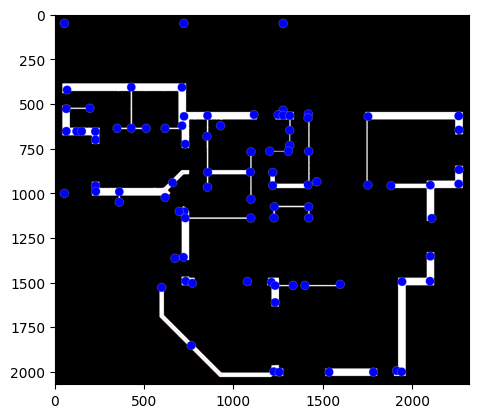

In [8]:
junctions = cluster_junctions(coords)
vis = visualize_junctions(cleaned, skeleton, junctions, branch_mask, corner_mask)
plt.imshow(vis)
plt.show()